**Import Libraries**

In [1]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import joblib

**Read File**

In [2]:
try:
    hd = pd.read_csv("heart_disease_uci_expanded.csv")
except FileNotFoundError:
    print("Dataset file not found. Check the file path.")
except pd.errors.EmptyDataError:
    print("The CSV file is empty.")
else:
    print("The CSV file loaded successfully.")

The CSV file loaded successfully.


In [3]:
required_columns = ['age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']

# check if the data set is correct
missing_cols = set(required_columns) - set(hd.columns)
if missing_cols:
    raise KeyError(f"Input data is missing expected columns: {missing_cols}")

# **Exploratory Data Analysis**

In [4]:
hd.tail(16)

,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
4984,43.0,Female,Hungary,atypical angina,144.0,206.0,False,normal,167.0,False,NaN,NaN,NaN,NaN,0
4985,47.0,Male,Hungary,asymptomatic,157.0,315.0,True,normal,154.0,True,-0.0,NaN,NaN,NaN,0
4986,58.0,Male,Hungary,atypical angina,130.0,194.0,False,normal,159.0,False,0.1,NaN,NaN,normal,0
4987,61.0,Male,VA Long Beach,asymptomatic,129.0,232.0,NaN,normal,135.0,True,4.2,downsloping,NaN,NaN,4
4988,61.0,Male,VA Long Beach,asymptomatic,150.0,212.0,True,normal,111.0,True,2.9,downsloping,NaN,NaN,1
4989,59.0,Female,Cleveland,atypical angina,118.0,225.0,False,lv hypertrophy,176.0,False,0.1,flat,1.0,normal,1
4990,55.0,Female,Hungary,atypical angina,123.0,275.0,False,normal,128.0,False,-0.1,NaN,NaN,NaN,0
4991,NaN,Male,Hungary,asymptomatic,136.0,238.0,False,normal,112.0,False,1.9,NaN,NaN,NaN,0
4992,65.0,Male,VA Long Beach,asymptomatic,130.0,197.0,True,normal,130.0,True,0.5,flat,NaN,NaN,1
4993,44.0,Female,Cleveland,non-anginal,NaN,207.0,False,normal,165.0,False,0.0,flat,0.0,normal,0


In [5]:
hd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       4973 non-null   float64
 1   sex       4978 non-null   object 
 2   dataset   5000 non-null   object 
 3   cp        4966 non-null   object 
 4   trestbps  4562 non-null   float64
 5   chol      4759 non-null   float64
 6   fbs       4326 non-null   object 
 7   restecg   4916 non-null   object 
 8   thalch    4613 non-null   float64
 9   exang     4603 non-null   object 
 10  oldpeak   4543 non-null   float64
 11  slope     3099 non-null   object 
 12  ca        1475 non-null   float64
 13  thal      2141 non-null   object 
 14  num       5000 non-null   int64  
dtypes: float64(6), int64(1), object(8)
memory usage: 586.1+ KB


Statistical Summary

In [6]:
hd.describe()

,age,trestbps,chol,thalch,oldpeak,ca,num
count,4973.000000,4562.00000,4759.000000,4613.000000,4543.000000,1475.000000,5000.000000
mean,53.566459,131.93402,199.626812,137.618686,0.875963,0.762712,1.037600
std,9.869495,22.58437,112.748974,27.167681,1.145011,0.958058,1.170496
min,18.000000,0.00000,0.000000,50.000000,-3.000000,0.000000,0.000000
25%,47.000000,118.00000,166.000000,119.000000,0.000000,0.000000,0.000000
50%,54.000000,130.00000,223.000000,139.000000,0.500000,0.000000,1.000000
75%,60.000000,145.00000,269.000000,158.000000,1.600000,1.000000,2.000000
max,102.000000,299.00000,795.000000,228.000000,8.700000,3.000000,4.000000


Missing Values

In [7]:
missing_counts = hd.isnull().sum()
missing_pct = (hd.isnull().mean() * 100).round(1)

missing_summary = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_pct": missing_pct
}).sort_values("missing_pct", ascending=False)

print(missing_summary[missing_summary["missing_count"] > 0])

          missing_count  missing_pct
ca                 3525         70.5
thal               2859         57.2
slope              1901         38.0
fbs                 674         13.5
oldpeak             457          9.1
trestbps            438          8.8
exang               397          7.9
thalch              387          7.7
chol                241          4.8
restecg              84          1.7
cp                   34          0.7
age                  27          0.5
sex                  22          0.4


Outlier Detection

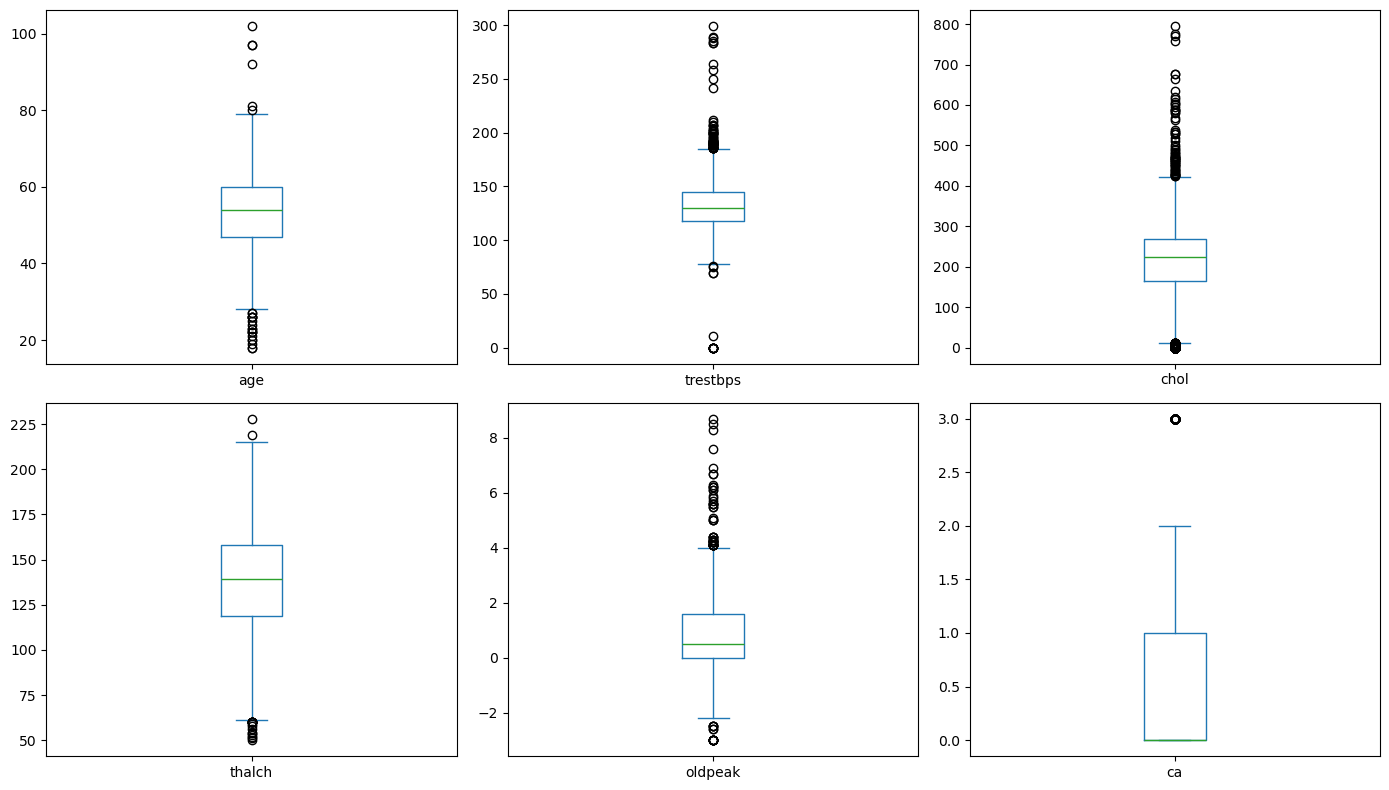

In [8]:
numeric_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']

hd[numeric_cols].plot(kind='box', subplots=True, layout=(2, 3), figsize=(14, 8))
plt.tight_layout()
plt.show()

In [9]:
def detect_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    return outliers, lower_bound, upper_bound

for col in numeric_cols:
    outliers, low, high = detect_outliers_iqr(hd, col)
    print(f"{col}: {len(outliers)} outliers (valid range: {low:.2f} to {high:.2f})")

age: 25 outliers (valid range: 27.50 to 79.50)
trestbps: 76 outliers (valid range: 77.50 to 185.50)
chol: 780 outliers (valid range: 11.50 to 423.50)
thalch: 19 outliers (valid range: 60.50 to 216.50)
oldpeak: 66 outliers (valid range: -2.40 to 4.00)
ca: 117 outliers (valid range: -1.50 to 2.50)


Class Balance Check

In [10]:
hd['num'].apply(lambda x: 1 if x > 0 else 0).value_counts()

num
1    2811
0    2189
Name: count, dtype: int64

Correlation Matrix

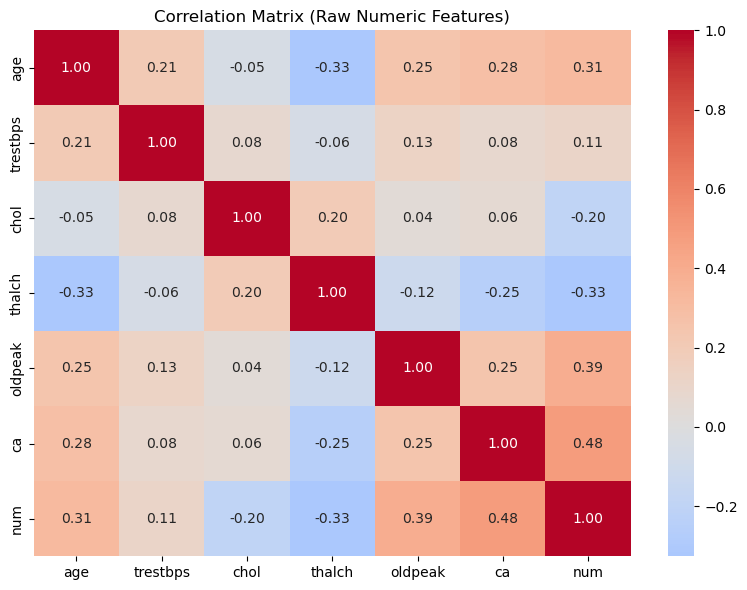

In [11]:
corr_matrix = hd[numeric_cols + ['num']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix (Raw Numeric Features)')
plt.tight_layout()
plt.show()

# **Preprocessing**

**Unnecessary Columns**

In [12]:
try:
    hd = hd.drop(columns=['dataset'])
except KeyError:
    print("Column 'dataset' was not found in DataFrame.")

**Duplicate Rows**

In [13]:
# duplicate rows
print("Duplicate rows:", hd.duplicated().sum())
hd = hd.drop_duplicates()
print("Duplicate rows after:", hd.duplicated().sum())

Duplicate rows: 4
Duplicate rows after: 0


**Missing Values**

In [14]:
numeric_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

# fix known placeholder zeros FIRST (0 is not a valid trestbps/chol reading)
# this must happen BEFORE the missing-value flags below, otherwise these
# rows won't be correctly counted as missing
hd.loc[hd['trestbps'] == 0, 'trestbps'] = None
hd.loc[hd['chol'] == 0, 'chol'] = None

# general flag: was ANY numeric value missing in this row
hd['data_was_missing'] = hd[numeric_cols].isnull().any(axis=1).astype(int)

# individual missing-indicators for the heaviest-missingness columns
# (worth tracking separately since ca/thal/slope are missing in the
# majority of rows in this expanded dataset - the missingness itself
# may carry signal, e.g. a test not being ordered)
heavy_missing_cols = ['ca', 'thal', 'slope']
for col in heavy_missing_cols:
    hd[col + '_was_missing'] = hd[col].isnull().astype(int)

**Create Target Variable**

In [15]:
# create the binary target variable
# num > 0 means some level of heart disease present, 0 means no heart disease
hd['heartdisease_binary'] = (hd['num'] > 0).astype(int)

**Feature Engineering**
(create columns that are safe before split)

creating chol_category column

In [16]:
def chol_category(val):
    if pd.isnull(val):
        return 'missing'
    elif val < 200:
        return 'normal'
    elif val < 240:
        return 'borderline'
    else:
        return 'high'

hd['chol_category'] = hd['chol'].apply(chol_category)

risk_flags

In [17]:
# count how many "risk flags" a patient has across binary indicators
# NaN comparisons evaluate to False, so this is safe to run before imputation
hd['risk_flag_count'] = (
    (hd['fbs'] == True).astype(int) +
    (hd['exang'] == True).astype(int) +
    (hd['oldpeak'] > 1).astype(int) +
    (hd['ca'] > 0).astype(int)
)

**Split into Train and Test datasets**

In [18]:
train, test = train_test_split(hd, test_size=0.2, random_state=42, stratify=hd['heartdisease_binary'])

**Imputing Missing Values**

In [19]:
numeric_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

# impute numeric columns with median (fit on train only)
for col in numeric_cols:
    median_val = train[col].median()
    train[col] = train[col].fillna(median_val)
    test[col] = test[col].fillna(median_val)

# impute categorical columns with 'missing'
for col in categorical_cols:
    train[col] = train[col].fillna('missing')
    test[col] = test[col].fillna('missing')

**Feature Engineering** 
Recalculate and add features that depend on the just imputed columns

In [20]:
for df in [train, test]:
    df['predicted_max_hr'] = 220 - df['age']
    df['age_group'] = pd.cut(df['age'], bins=[0, 40, 50, 60, 70, 100],
                              labels=['<40', '40-50', '50-60', '60-70', '70+'])
    df['oldpeak_x_flat_slope'] = df['oldpeak'] * (df['slope'] == 'flat').astype(int)
    df['hr_reserve'] = df['predicted_max_hr'] - df['thalch']
    df['bp_age_ratio'] = df['trestbps'] / df['age']
    df['vessel_thal_severity'] = df['ca'] + (df['thal'] == 'reversable defect').astype(int) * 2

Class Imbalance Check

In [21]:
hd['num'].apply(lambda x: 1 if x > 0 else 0).value_counts()

num
1    2810
0    2186
Name: count, dtype: int64

# **Data Representation**

**one-hot encode categorical columns**

In [22]:
cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal', 'chol_category', 'age_group']
train = pd.get_dummies(train, columns=cat_cols, drop_first=True)
test = pd.get_dummies(test, columns=cat_cols, drop_first=True)
train, test = train.align(test, join='left', axis=1, fill_value=0)

**Derive X (features) and y (target)**

In [23]:
# drop BOTH num and heartdisease_binary from features
X_train_raw = train.drop(columns=['num', 'heartdisease_binary'])
y_train = train['heartdisease_binary']

X_test_raw = test.drop(columns=['num', 'heartdisease_binary'])
y_test = test['heartdisease_binary']

# sanity check - should be empty now, since imputation already happened
nan_counts = X_train_raw.isnull().sum()
print(nan_counts[nan_counts > 0])

Series([], dtype: int64)


**Feature Selection**

In [24]:
selector = SelectKBest(score_func=f_classif, k=30)

# fit on train only, then transform both
X_train_selected = selector.fit_transform(X_train_raw, y_train)
X_test_selected = selector.transform(X_test_raw)

# get the names of the columns that were selected
selected_mask = selector.get_support()
selected_features = X_train_raw.columns[selected_mask]

# turn the results back into DataFrames with proper column names
X_train = pd.DataFrame(X_train_selected, columns=selected_features, index=X_train_raw.index)
X_test = pd.DataFrame(X_test_selected, columns=selected_features, index=X_test_raw.index)

print("Selected features:", selected_features.tolist(), "\n")
print("X_train shape:", X_train.shape, "\n")

feature_scores = pd.DataFrame({
    'feature': X_train_raw.columns,
    'score': selector.scores_
}).sort_values('score', ascending=False)

#print(feature_scores)

Selected features: ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'data_was_missing', 'ca_was_missing', 'slope_was_missing', 'risk_flag_count', 'predicted_max_hr', 'oldpeak_x_flat_slope', 'hr_reserve', 'bp_age_ratio', 'vessel_thal_severity', 'sex_Male', 'cp_atypical angina', 'cp_non-anginal', 'fbs_missing', 'restecg_st-t abnormality', 'exang_True', 'slope_flat', 'slope_missing', 'slope_upsloping', 'thal_normal', 'thal_reversable defect', 'chol_category_missing', 'age_group_40-50', 'age_group_50-60', 'age_group_60-70'] 

X_train shape: (3996, 30) 



In [25]:
y_train

1783    1
4661    1
1343    1
2089    1
1159    0
       ..
1168    1
1026    0
965     1
1420    0
1106    1
Name: heartdisease_binary, Length: 3996, dtype: int64

In [26]:
X_train

,age,trestbps,chol,thalch,oldpeak,ca,data_was_missing,ca_was_missing,slope_was_missing,risk_flag_count,...,exang_True,slope_flat,slope_missing,slope_upsloping,thal_normal,thal_reversable defect,chol_category_missing,age_group_40-50,age_group_50-60,age_group_60-70
1783,52.0,147.0,1.0,153.0,3.1,0.0,1.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4661,60.0,142.0,233.0,80.0,1.9,0.0,1.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0
1343,61.0,125.0,233.0,126.0,0.4,0.0,1.0,1.0,0.0,1.0,...,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
2089,60.0,140.0,293.0,170.0,1.2,2.0,0.0,0.0,0.0,2.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1159,64.0,110.0,211.0,144.0,1.8,0.0,0.0,0.0,0.0,2.0,...,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1168,57.0,170.0,233.0,122.0,-0.0,0.0,1.0,1.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0
1026,39.0,160.0,147.0,160.0,0.0,0.0,1.0,1.0,1.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
965,57.0,149.0,300.0,96.0,1.5,0.0,1.0,1.0,0.0,3.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1420,43.0,137.0,289.0,168.0,0.0,0.0,1.0,1.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


**Standard Scaling**

In [27]:
# identify truly binary columns (only contain 0/1)
binary_cols = [col for col in X_train.columns
               if X_train[col].dropna().nunique() <= 2
               and set(X_train[col].dropna().unique()).issubset({0, 1})]

# identify continuous columns
continuous_cols = [col for col in X_train.columns if col not in binary_cols]

print("Scaling these columns:", continuous_cols, "\n")
print("Leaving these as-is (binary):", binary_cols)

# scaling
scaler = StandardScaler()
X_train[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test[continuous_cols] = scaler.transform(X_test[continuous_cols])

# save the fitted scaler 
#joblib.dump(scaler, 'scaler.pkl')

# also save which columns need scaling, so app.py knows exactly which ones
#joblib.dump(continuous_cols, 'scaled_columns.pkl')

Scaling these columns: ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'risk_flag_count', 'predicted_max_hr', 'oldpeak_x_flat_slope', 'hr_reserve', 'bp_age_ratio', 'vessel_thal_severity'] 

Leaving these as-is (binary): ['data_was_missing', 'ca_was_missing', 'slope_was_missing', 'sex_Male', 'cp_atypical angina', 'cp_non-anginal', 'fbs_missing', 'restecg_st-t abnormality', 'exang_True', 'slope_flat', 'slope_missing', 'slope_upsloping', 'thal_normal', 'thal_reversable defect', 'chol_category_missing', 'age_group_40-50', 'age_group_50-60', 'age_group_60-70']


Correlations against Target Variable (heartdisease_binary)

In [28]:
correlations_with_target = hd.select_dtypes(include=['number']).corr()['heartdisease_binary'].sort_values(ascending=False).drop('num')
print(correlations_with_target)

heartdisease_binary    1.000000
ca                     0.407088
risk_flag_count        0.365484
oldpeak                0.321543
age                    0.254569
data_was_missing       0.092914
ca_was_missing         0.090765
trestbps               0.086096
thal_was_missing      -0.030815
chol                  -0.086861
slope_was_missing     -0.194516
thalch                -0.321981
Name: heartdisease_binary, dtype: float64


**Save processed data**

In [29]:
# save the train/test data so it can be loaded in a different notebook
try:
    joblib.dump(X_train, 'X_train.pkl')
    joblib.dump(X_test, 'X_test.pkl')
    joblib.dump(y_train, 'y_train.pkl')
    joblib.dump(y_test, 'y_test.pkl')
    joblib.dump(X_train_raw, 'X_train_raw.pkl')
    joblib.dump(X_test_raw, 'X_test_raw.pkl')

except (PermissionError, OSError) as e:
    print(f"Failed to save output files: {e}")

else:
    print("Data saved successfully!")

Data saved successfully!


In [30]:
print(list(X_train.columns))

['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'data_was_missing', 'ca_was_missing', 'slope_was_missing', 'risk_flag_count', 'predicted_max_hr', 'oldpeak_x_flat_slope', 'hr_reserve', 'bp_age_ratio', 'vessel_thal_severity', 'sex_Male', 'cp_atypical angina', 'cp_non-anginal', 'fbs_missing', 'restecg_st-t abnormality', 'exang_True', 'slope_flat', 'slope_missing', 'slope_upsloping', 'thal_normal', 'thal_reversable defect', 'chol_category_missing', 'age_group_40-50', 'age_group_50-60', 'age_group_60-70']
